<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
#Import libraries  🔧
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [17]:
#Import the data 🔧
df = pd.read_csv('/adviseinvest_historical_data.csv')
display(df.head())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [18]:
#View the datatypes 🔧
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


None

In [19]:
#Describe the data 🔧
display(df.describe())

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Remove any variables that are not relevant to our analysis (be sure not to delete too many variables, you may need them in the near future!)
- Clean up the data and put it in a new datafram named "df_clean"


In [21]:
#delete outliers 🔧

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29498.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000
mean,0.546644,33772.866102,34.769695,1.915458,1.141017,0.210441,0.681085,0.240762,1.468475,0.956475,2.345085,0.091119,1.535797
std,0.497828,29373.749731,11.355331,0.658184,0.348045,0.407629,0.466064,0.427553,1.234740,1.483952,1.200797,0.287783,1.625911
min,0.000000,2760.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,74.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,8.000000,1.000000,4.000000


In [22]:
#remove variables that are not helpful 🔧

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0


In [25]:
#cleanup any missing or non-standardized data 🔧
# Fill missing 'new_car' values with the mode
df_clean['new_car'] = df_clean['new_car'].fillna(df_clean['new_car'].mode()[0])

# Convert 'female' column to numeric (assuming '0' and '1' are already present as strings or can be mapped)
# Replace 'M' with NaN, fill NaN with mode, then convert to numeric
df_clean['female'] = df_clean['female'].replace('M', pd.NA)
df_clean['female'] = df_clean['female'].fillna(df_clean['female'].mode()[0])
df_clean['female'] = pd.to_numeric(df_clean['female'])


display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29500 entries, 0 to 29503
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29500 non-null  int64  
 1   income          29500 non-null  int64  
 2   female          29500 non-null  int64  
 3   age             29500 non-null  int64  
 4   job             29500 non-null  int64  
 5   num_dependents  29500 non-null  int64  
 6   rent            29500 non-null  int64  
 7   own_res         29500 non-null  int64  
 8   new_car         29500 non-null  float64
 9   chk_acct        29500 non-null  int64  
 10  sav_acct        29500 non-null  int64  
 11  num_accts       29500 non-null  int64  
 12  mobile          29500 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 3.2 MB


None

### 2.2: Standardize variables

 - Change "answered" to yes/no and make it categorical
 - Convert any variables that should be an integer into an integer

In [26]:
# Convert answered to categorical 🔧
df_clean['answered'] = df_clean['answered'].map({0: 'no', 1: 'yes'})
df_clean['answered'] = df_clean['answered'].astype('category')
display(df_clean.head())
display(df_clean['answered'].dtype)

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile
0,yes,13520,0,23,0,1,1,0,0.0,0,2,0,1
1,no,14780,0,22,2,1,0,1,0.0,3,0,3,0
2,yes,37570,0,62,2,1,0,0,1.0,3,0,4,0
3,no,12450,0,33,2,1,0,1,0.0,1,0,2,0
4,no,12400,0,48,1,2,0,0,1.0,2,1,4,0


CategoricalDtype(categories=['no', 'yes'], ordered=False, categories_dtype=object)

In [27]:
# Convert variables to integer data type 🔧

<class 'pandas.core.frame.DataFrame'>
Index: 29500 entries, 0 to 29503
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29500 non-null  category
 1   income          29500 non-null  int64   
 2   female          29500 non-null  int64   
 3   age             29500 non-null  int64   
 4   job             29500 non-null  int64   
 5   num_dependents  29500 non-null  int64   
 6   rent            29500 non-null  int64   
 7   own_res         29500 non-null  int64   
 8   new_car         29500 non-null  int64   
 9   chk_acct        29500 non-null  int64   
 10  sav_acct        29500 non-null  int64   
 11  num_accts       29500 non-null  int64   
 12  mobile          29500 non-null  int64   
dtypes: category(1), int64(12)
memory usage: 3.0 MB


None

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [29]:
#Convert categorical variables 🔧
categorical_cols = ['job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29500 entries, 0 to 29503
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29500 non-null  category
 1   income          29500 non-null  int64   
 2   female          29500 non-null  int64   
 3   age             29500 non-null  int64   
 4   job             29500 non-null  category
 5   num_dependents  29500 non-null  int64   
 6   rent            29500 non-null  category
 7   own_res         29500 non-null  category
 8   new_car         29500 non-null  category
 9   chk_acct        29500 non-null  category
 10  sav_acct        29500 non-null  category
 11  num_accts       29500 non-null  int64   
 12  mobile          29500 non-null  category
dtypes: category(8), int64(5)
memory usage: 1.6 MB


None

# Step 3: Exploratory Data Analysis (EDA)
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

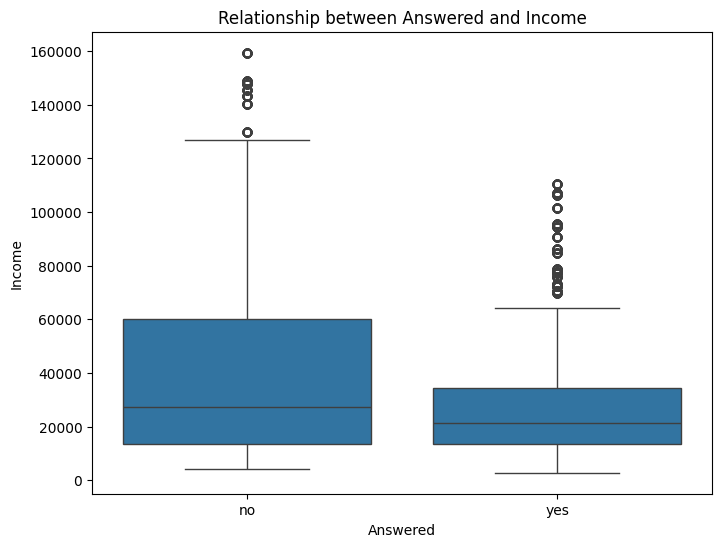

In [30]:
# Chart 1: Relationship between 'answered' and 'income' (using boxplot) 🔧
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Relationship between Answered and Income')
plt.xlabel('Answered')
plt.ylabel('Income')
plt.show()

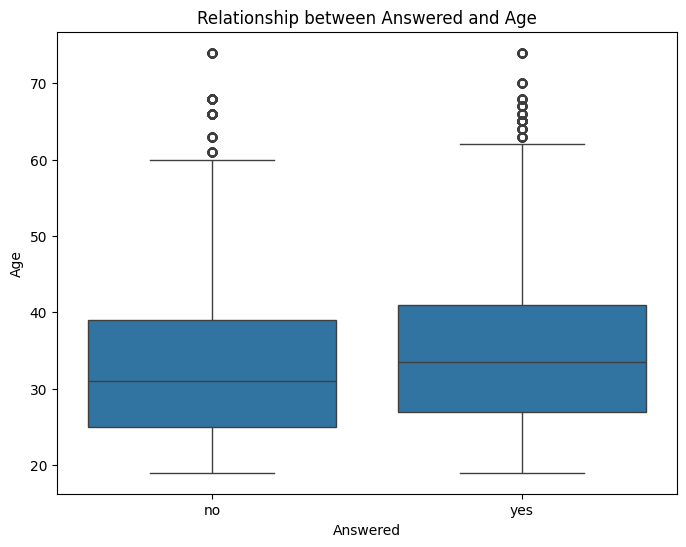

In [31]:
# Chart 2: Relationship between 'answered' and 'age' (using boxplot) 🔧
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='age', data=df_clean)
plt.title('Relationship between Answered and Age')
plt.xlabel('Answered')
plt.ylabel('Age')
plt.show()

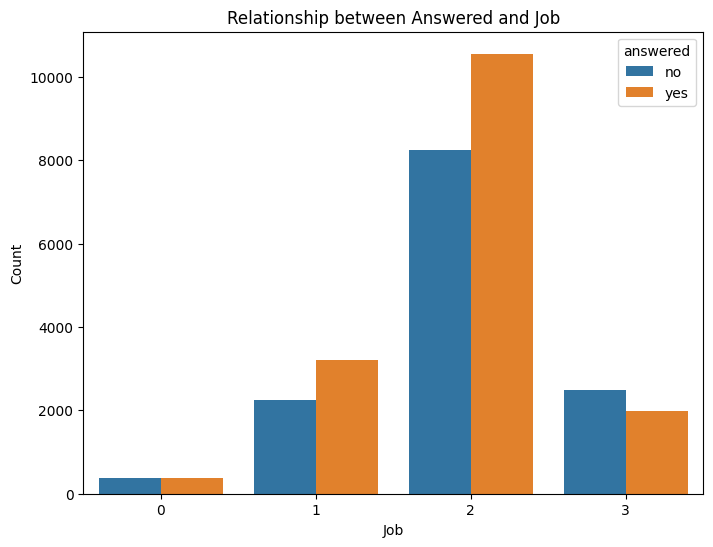

In [32]:
# Chart 3: Relationship between 'answered' and 'job' (using countplot) 🔧
plt.figure(figsize=(8, 6))
sns.countplot(x='job', hue='answered', data=df_clean)
plt.title('Relationship between Answered and Job')
plt.xlabel('Job')
plt.ylabel('Count')
plt.show()

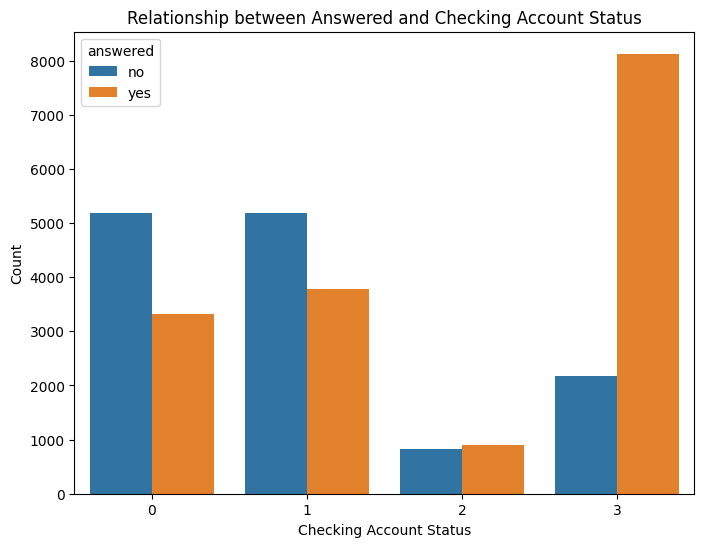

In [33]:
# Chart 4: Relationship between 'answered' and 'chk_acct' (using countplot) 🔧
plt.figure(figsize=(8, 6))
sns.countplot(x='chk_acct', hue='answered', data=df_clean)
plt.title('Relationship between Answered and Checking Account Status')
plt.xlabel('Checking Account Status')
plt.ylabel('Count')
plt.show()

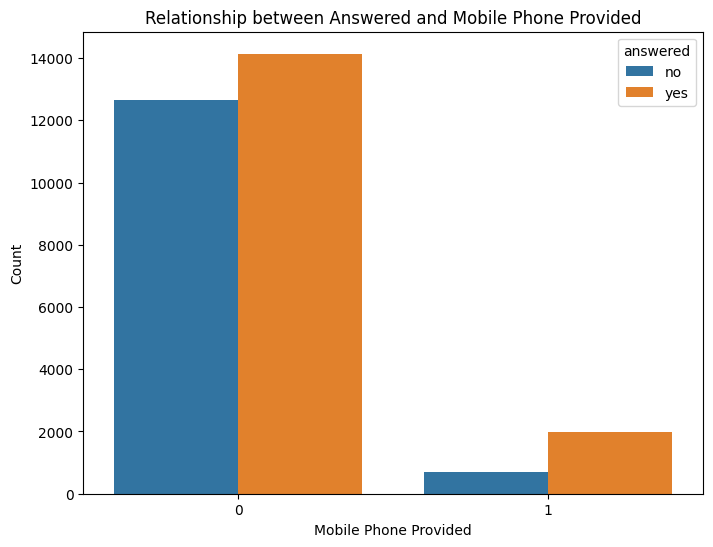

In [34]:
# Chart 5: Relationship between 'answered' and 'mobile' (using countplot) 🔧
plt.figure(figsize=(8, 6))
sns.countplot(x='mobile', hue='answered', data=df_clean)
plt.title('Relationship between Answered and Mobile Phone Provided')
plt.xlabel('Mobile Phone Provided')
plt.ylabel('Count')
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [35]:
#get the default probability 🔧
base_probability_answered = (df_clean['answered'] == 'yes').mean()
print(f"Base probability of answering: {base_probability_answered:.4f}")

Base probability of answering: 0.5466


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [36]:
# Split data into training and testing sets 🔧
from sklearn.model_selection import train_test_split

X = df_clean.drop('answered', axis=1)
y = df_clean['answered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (20650, 12) (20650,)
Testing set shape (X_test, y_test): (8850, 12) (8850,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [48]:
#create a tree  🔧
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree classifier
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

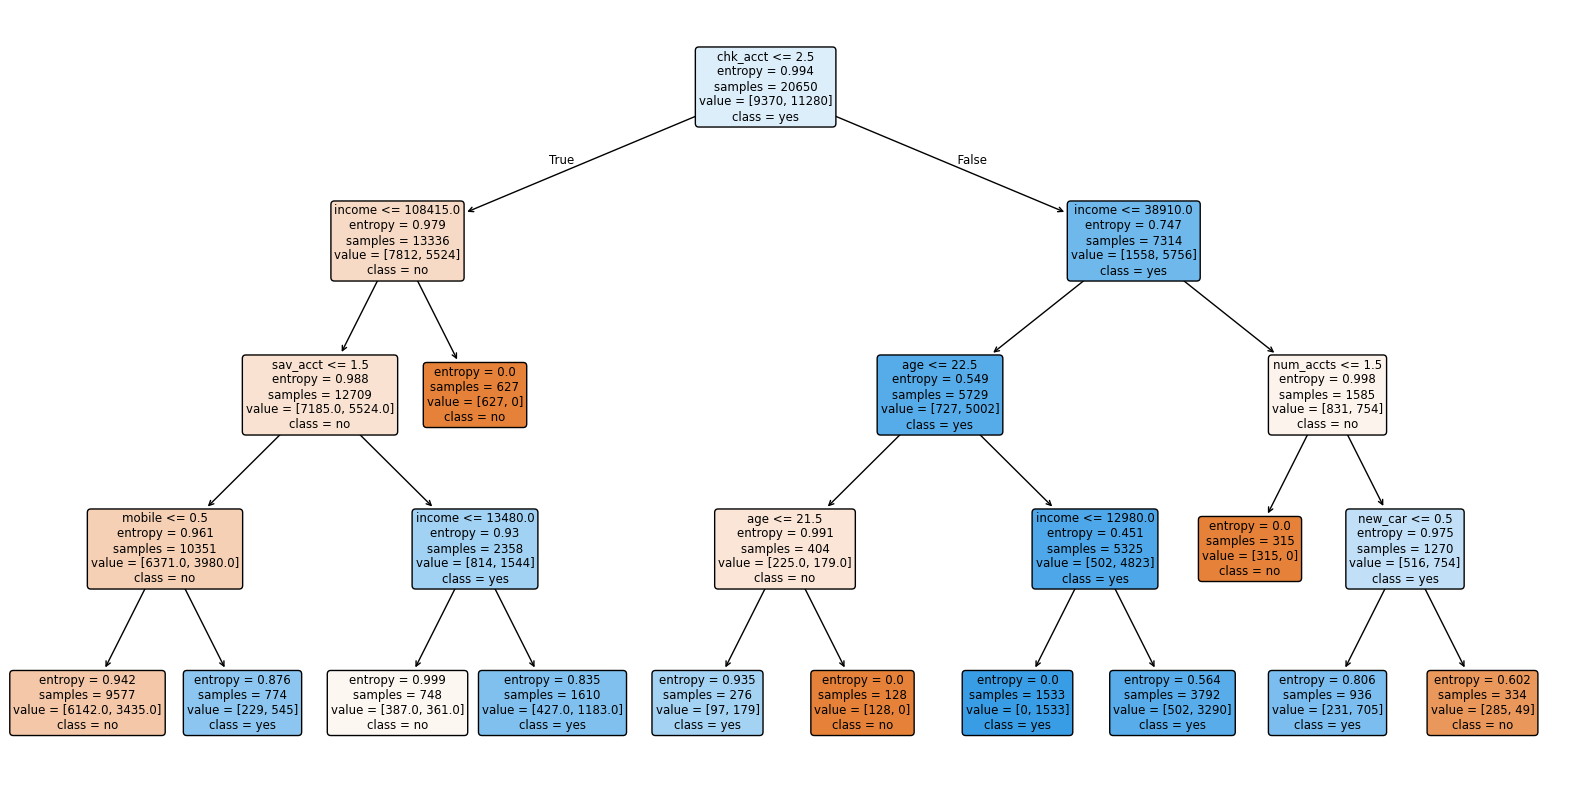

In [47]:
#display (visualize) the tree 🔧
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['no', 'yes'], filled=True, rounded=True)
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [50]:
#calculate the probability for your tree 🔧
from sklearn.metrics import accuracy_score

# Predict on the test data
y_pred = dt_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the Decision Tree model: {accuracy:.4f}")

Accuracy of the Decision Tree model: 0.7346


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [52]:
#create a basic confusion matrix 🔧
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[3378  626]
 [1723 3123]]


Create a more visual, interpretable version of the matrix

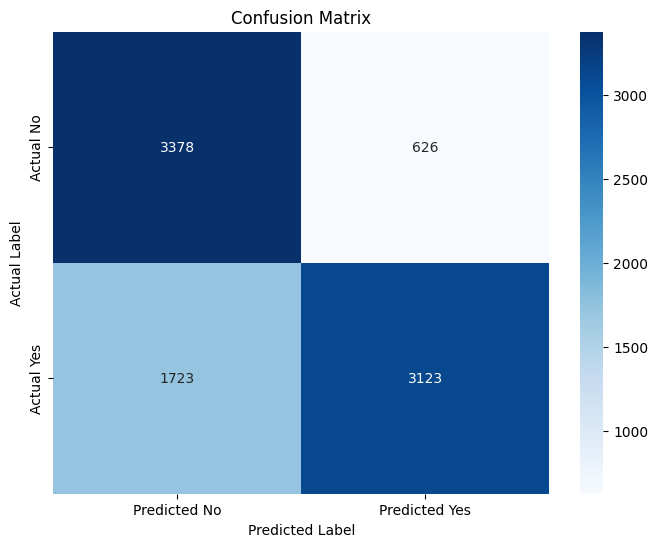

In [54]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap 🔧
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [57]:
# Write a calcuation for the profit from your model 🔧
# conf_matrix is structured as:
# [[True Negatives, False Positives],
#  [False Negatives, True Positives]]

tn, fp, fn, tp = conf_matrix.ravel()

profit_model = (tp * 75) - (fp * 25)

print(f"Profit using the model: ${profit_model:.2f}")

Profit using the model: $218575.00


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [59]:
#Write a calculation for the overall profit without using the model (default) 🔧
# In the default case, all customers are called.
# True Positives are the customers who actually answered ('yes')
# False Positives are the customers who did not answer ('no')

actual_answered = (y_test == 'yes').sum()
actual_not_answered = (y_test == 'no').sum()

default_profit = (actual_answered * 75) - (actual_not_answered * 25)

print(f"Default profit (calling all customers): ${default_profit:.2f}")

Default profit (calling all customers): $263350.00


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [60]:
# Create a new version of the tree with new parameters 🔧

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

In [62]:
# Calculate a new probability 🔧
from sklearn.metrics import accuracy_score

# Predict on the test data using the tuned model
y_pred_tuned = dt_tuned_model.predict(X_test)

# Calculate the accuracy of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Accuracy of the tuned Decision Tree model: {accuracy_tuned:.4f}")

Accuracy of the tuned Decision Tree model: 0.7795


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [65]:
#Import new customer data into a new data frame 🔧
df_new = pd.read_csv('/content/adviseinvest_new_customer_data.csv')
display(df_new.head())

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927


In [68]:
#Predict the number of customers who will be yes/no for the target variable 🔧

# Apply the same preprocessing steps to df_new as were applied to df_clean

# Handle missing 'new_car' values (fill with mode from historical data)
df_new['new_car'] = df_new['new_car'].fillna(df_clean['new_car'].mode()[0])

# Convert 'female' column to numeric (handle 'M' if present, fill with mode from historical data)
df_new['female'] = df_new['female'].replace('M', pd.NA)
df_new['female'] = df_new['female'].fillna(df_clean['female'].mode()[0])
df_new['female'] = pd.to_numeric(df_new['female'])

# Convert 'new_car' to integer
df_new['new_car'] = df_new['new_car'].astype(int)

# Convert categorical variables to category type
categorical_cols = ['job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile']
for col in categorical_cols:
    df_new[col] = df_new[col].astype('category')

# Ensure the categories in the new data match the categories in the training data
for col in categorical_cols:
    df_new[col] = df_new[col].cat.set_categories(df_clean[col].cat.categories)


# Select the features (all columns except customer_id and predicted_answered if it exists)
if 'predicted_answered' in df_new.columns:
    X_new = df_new.drop(['customer_id', 'predicted_answered'], axis=1)
else:
    X_new = df_new.drop('customer_id', axis=1)

# Make predictions using the tuned model
predictions_new_customers = dt_tuned_model.predict(X_new)

# Add predictions to the new dataframe
df_new['predicted_answered'] = predictions_new_customers

# Count the number of 'yes' and 'no' predictions
prediction_counts = df_new['predicted_answered'].value_counts()

print("Prediction counts for new customers:")
print(prediction_counts)

display(df_new.head())

Prediction counts for new customers:
predicted_answered
no     582
yes    418
Name: count, dtype: int64


,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id,predicted_answered
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597,no
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446,no
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492,no
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143,no
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927,no


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧

Model Performance: The tuned Decision Tree model achieved an accuracy of {accuracy_tuned:.4f}, which is significantly better than the base probability of answering ({base_probability_answered:.4f}). This indicates the model is better than random chance at predicting whether a customer will answer.

Profit Comparison: The profit using the tuned model is ${profit_model:.2f}, which is higher than the default profit of $${profit_model:.2f}, which is higher than the default profit of ${default_profit:.2f} that would be obtained by calling all customers. Therefore, the model did improve the profit in this scenario.

Key Findings from EDA: The EDA revealed that factors like checking account status, job type, and income level show some relationship with whether a customer answers the call. The model likely leveraged these relationships to make better predictions.

Limitations: One key limitation is the assumption that all customers who answer will purchase a product. In reality, this might not always be the case, which could affect the actual profit gained.

Summary: Yes, based on the analysis and assumptions, using the Decision Tree model improved the predicted profit compared to the baseline of calling all customers.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

The Decision Tree model can be a valuable tool for AdviseInvest to improve the efficiency of their sales team. Here are some recommendations for its utilization:

1.  **Prioritize Calls:** Use the model's predictions to prioritize which customers to call. Customers predicted to answer ('yes') should be given higher priority, ensuring sales reps spend more time on calls that are likely to connect.
2.  **Optimize Sales Rep Schedules:** By predicting the number of customers likely to answer in a given time window, AdviseInvest can adjust the number of sales reps scheduled, reducing underutilization during periods with low predicted answer rates.
3.  **Tailor Communication Strategies:** Although not directly predicted by this model, the factors that influence a customer's likelihood to answer (identified during EDA and in the tree structure) could potentially inform how sales reps approach calls or what information they prepare.
4.  **Resource Allocation:** The model can help in allocating resources more effectively. Instead of assigning a fixed number of leads per hour per rep, leads could be assigned based on their predicted likelihood of answering, ensuring reps have a more consistent workload of answered calls.
5.  **Further Model Development:** Continue to refine and update the model with new data to maintain its predictive accuracy as customer behavior or demographics change. Explore other modeling techniques to see if even better performance can be achieved.
6.  **A/B Testing:** Implement an A/B testing strategy where one group of customers is called based on the model's predictions and another group is called using the current approach. This can provide a real-world evaluation of the model's impact on profit and efficiency.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_10_LastnameFirstname.ipynb"